In [23]:
import os
import json
import librosa
import numpy as np
import soundfile as sf
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

In [2]:
# Rutas
PATHS = {
    'raw_dataset': 'data/raw/LJSpeech-1.1',
    'output_audios': 'data/processed/audios',
    'output_texts': 'data/processed/texts',
    'output_metadata': 'data/processed/metadata'
}

In [4]:
CONFIG = {
    'sample_rate': 22050,
    'chunk_duration': 10.0,  # Segundos
    'train_test_split': 0.9,  # 90% train, 10% test
    'normalize_audio': True
}

In [5]:
# Crear carpetas
for folder in PATHS.values():
    os.makedirs(folder, exist_ok=True)
    print(f"✓ {folder}")

print(f"Configuración:")
print(f"Sample rate: {CONFIG['sample_rate']} Hz")
print(f"Chunk duration: {CONFIG['chunk_duration']} segundos")
print(f"Train/Test split: {CONFIG['train_test_split']}\n")

✓ data/raw/LJSpeech-1.1
✓ data/processed/audios
✓ data/processed/texts
✓ data/processed/metadata
Configuración:
Sample rate: 22050 Hz
Chunk duration: 10.0 segundos
Train/Test split: 0.9



### Cargar dataset original

In [6]:
dataset_path = Path(PATHS['raw_dataset'])
wavs_folder = dataset_path / 'wavs'
metadata_file = dataset_path / 'metadata.csv'

In [7]:
# Listar archivos
wav_files = sorted([f for f in os.listdir(wavs_folder) if f.endswith('.wav')])
print(f"Total de archivos: {len(wav_files)}")

Total de archivos: 13100


In [8]:
# Cargar metadata
metadata_dict = {}
with open(metadata_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('|')
        if len(parts) >= 2:
            filename = parts[0]
            transcription = parts[1]
            metadata_dict[filename] = transcription

print(f"Total de transcripciones: {len(metadata_dict)}\n")

Total de transcripciones: 13100



In [10]:
# Mostrar ejemplo
example_file = wav_files[0]
example_text = metadata_dict.get(example_file, "N/A")
print(f"Ejemplo:")
print(f"Archivo: {example_file}")
print(f"Transcripción: {example_text}\n")

Ejemplo:
Archivo: LJ001-0001.wav
Transcripción: N/A



### Procesar audios

In [ ]:
# Normaliza audio al formato esperado por VITS2
def normalizar_audio(audio, target_sr=22050):
    # Peak normalization
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    
    # Asegurar rango [-1, 1]
    audio = np.clip(audio, -1, 1)
    
    return audio

In [14]:
# Procesa un archivo de audio

def procesar_archivo(wav_path, transcription, output_folder, chunk_id):
    try:
        # Cargar audio
        audio, sr = librosa.load(str(wav_path), sr=22050)
        
        # Normalizar
        audio = normalizar_audio(audio)
        
        # Guardar
        output_path = Path(output_folder) / f"chunk_{chunk_id:06d}.wav"
        sf.write(str(output_path), audio, 22050)
        
        # Información
        duration = len(audio) / 22050
        
        return {
            'chunk_id': f"{chunk_id:06d}",
            'audio_path': str(output_path),
            'duration': duration,
            'transcription': transcription,
            'original_file': wav_path.name
        }
    except Exception as e:
        print(f"Error procesando {wav_path}: {e}")
        return None

In [15]:
audio_info_list = []
chunk_counter = 0

for idx, wav_file in enumerate(wav_files):
    wav_path = wavs_folder / wav_file
    transcription = metadata_dict.get(wav_file, "")
    
    # Procesar
    info = procesar_archivo(
        wav_path, 
        transcription, 
        PATHS['output_audios'],
        chunk_counter
    )
    
    if info:
        audio_info_list.append(info)
        chunk_counter += 1
    
    # Mostrar progreso
    if (idx + 1) % 1000 == 0:
        print(f"   [{idx+1}/{len(wav_files)}] Procesados")

print(f"Total de archivos procesados: {chunk_counter}\n")

   [1000/13100] Procesados
   [2000/13100] Procesados
   [3000/13100] Procesados
   [4000/13100] Procesados
   [5000/13100] Procesados
   [6000/13100] Procesados
   [7000/13100] Procesados
   [8000/13100] Procesados
   [9000/13100] Procesados
   [10000/13100] Procesados
   [11000/13100] Procesados
   [12000/13100] Procesados
   [13000/13100] Procesados
Total de archivos procesados: 13100



### Crear estructura de training

In [17]:
np.random.seed(42)
indices = np.arange(len(audio_info_list))
np.random.shuffle(indices)

split_point = int(len(audio_info_list) * CONFIG['train_test_split'])
train_indices = indices[:split_point]
test_indices = indices[split_point:]

print(f"División train/test:")
print(f"Training: {len(train_indices)} ejemplos ({len(train_indices)/len(audio_info_list)*100:.1f}%)")
print(f"Testing: {len(test_indices)} ejemplos ({len(test_indices)/len(audio_info_list)*100:.1f}%)\n")

División train/test:
Training: 11790 ejemplos (90.0%)
Testing: 1310 ejemplos (10.0%)



In [18]:
# Crear listas en formato VITS2
# Formato: audio_path|transcription|speaker_id
train_list = []
test_list = []

for idx in train_indices:
    info = audio_info_list[idx]
    # Ruta relativa
    rel_path = f"audios/chunk_{info['chunk_id']}.wav"
    line = f"{rel_path}|{info['transcription']}|0"  # speaker_id=0 para single-speaker
    train_list.append(line)

for idx in test_indices:
    info = audio_info_list[idx]
    rel_path = f"audios/chunk_{info['chunk_id']}.wav"
    line = f"{rel_path}|{info['transcription']}|0"
    test_list.append(line)

# Guardar listas
train_path = Path(PATHS['output_texts']) / 'train.txt'
test_path = Path(PATHS['output_texts']) / 'test.txt'

with open(train_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_list))

with open(test_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(test_list))

print(f"✓ Listas de training creadas:")
print(f"   - {train_path}")
print(f"   - {test_path}\n")

✓ Listas de training creadas:
   - data/processed/texts/train.txt
   - data/processed/texts/test.txt



### Crear modelo del dataset

In [21]:
metadata = {
    'dataset_name': 'LJ Speech - Preparado para VITS2',
    'speaker': 'LJ (Linda Johnson)',
    'language': 'English',
    'total_files': len(audio_info_list),
    'train_files': len(train_indices),
    'test_files': len(test_indices),
    'total_duration_seconds': sum([info['duration'] for info in audio_info_list]),
    'sample_rate': CONFIG['sample_rate'],
    'paper': 'VITS2: Improving Quality and Efficiency of Single-Stage Text-to-Speech',
    'repository': 'https://github.com/daniilrobnikov/vits2',
    'audio_format': 'WAV, mono, 22.05 kHz, normalized',
    'config': CONFIG
}

metadata['total_duration_hours'] = metadata['total_duration_seconds'] / 3600

metadata_path = Path(PATHS['output_metadata']) / 'dataset_info.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata guardada en: {metadata_path}\n")

print(f"Resumen del dataset:")
print(f"Total de archivos: {metadata['total_files']}")
print(f"Duración total: {metadata['total_duration_hours']:.2f} horas")
print(f"Duración promedio por archivo: {metadata['total_duration_seconds']/metadata['total_files']:.2f} segundos")
print(f"Training: {metadata['train_files']} ejemplos")
print(f"Testing: {metadata['test_files']} ejemplos\n")


Metadata guardada en: data/processed/metadata/dataset_info.json

Resumen del dataset:
Total de archivos: 13100
Duración total: 23.92 horas
Duración promedio por archivo: 6.57 segundos
Training: 11790 ejemplos
Testing: 1310 ejemplos



### Visualizar estadísticas

In [24]:
durations = [info['duration'] for info in audio_info_list]
durations = np.array(durations)

print(f"Estadísticas de duración:")
print(f"Mínima: {durations.min():.2f} segundos")
print(f" Máxima: {durations.max():.2f} segundos")
print(f"Promedio: {durations.mean():.2f} segundos")
print(f"Mediana: {np.median(durations):.2f} segundos")
print(f" Desv. Estándar: {durations.std():.2f} segundos\n")

Estadísticas de duración:
Mínima: 1.11 segundos
 Máxima: 10.10 segundos
Promedio: 6.57 segundos
Mediana: 6.76 segundos
 Desv. Estándar: 2.19 segundos



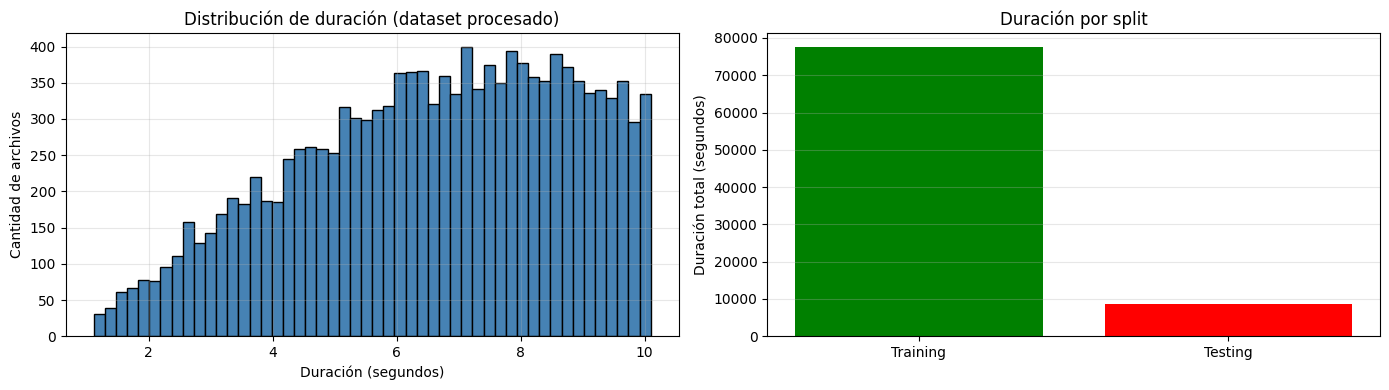

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(durations, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Duración (segundos)')
axes[0].set_ylabel('Cantidad de archivos')
axes[0].set_title('Distribución de duración (dataset procesado)')
axes[0].grid(True, alpha=0.3)

# Duración acumulada
axes[1].bar(['Training', 'Testing'], 
            [sum(durations[i] for i in train_indices), 
             sum(durations[i] for i in test_indices)],
            color=['green', 'red'])
axes[1].set_ylabel('Duración total (segundos)')
axes[1].set_title('Duración por split')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()